In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
LABELS_PATH = r"labels.csv"
EEG_FOLDER = r"MI CSV"

print("Labels file exists:", os.path.exists(LABELS_PATH))
print("EEG folder exists:", os.path.exists(EEG_FOLDER))

Labels file exists: True
EEG folder exists: True


In [4]:
labels_df = pd.read_csv(LABELS_PATH)

print("Shape:", labels_df.shape)
print("\nColumns:")
print(labels_df.columns.tolist())

labels_df.head()

Shape: (2400, 1)

Columns:
['label']


,label
0,Left
1,Right
2,Left
3,Left
4,Left


In [5]:
labels_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   2400 non-null   str  
dtypes: str(1)
memory usage: 29.4 KB


In [6]:
labels_df["label"].value_counts()

label
Right    1213
Left     1187
Name: count, dtype: int64

In [7]:
labels_df["label"].unique()

<ArrowStringArray>
['Left', 'Right']
Length: 2, dtype: str

In [8]:
eeg_files = glob.glob(os.path.join(EEG_FOLDER, "*.csv"))

print("Number of EEG CSV files:", len(eeg_files))

Number of EEG CSV files: 2160


In [9]:
for file in eeg_files[:10]:
    print(os.path.basename(file))

cellula_MI_data_1.csv
cellula_MI_data_10.csv
cellula_MI_data_100.csv
cellula_MI_data_1000.csv
cellula_MI_data_1001.csv
cellula_MI_data_1002.csv
cellula_MI_data_1003.csv
cellula_MI_data_1004.csv
cellula_MI_data_1005.csv
cellula_MI_data_1006.csv


In [ ]:
sample_file = eeg_files[0]
sample_df = pd.read_csv(sample_file)

print("File:", sample_file)
print("Shape:", sample_df.shape)

sample_df.head()

File: MI CSV\cellula_MI_data_1.csv
Shape: (2500, 5)


,Time,FZ,C3,CZ,C4
0,88451.201876,324761.37500,321002.62500,335287.28125,321417.90625
1,88451.221777,325001.18750,321223.09375,335409.56250,320937.09375
2,88451.221788,324896.75000,321045.53125,334954.40625,320233.56250
3,88451.229576,324627.28125,320756.12500,334589.43750,320262.25000
4,88451.229588,324538.31250,320729.21875,334804.56250,321010.50000


In [11]:
sample_df.columns.tolist()

['Time', 'FZ', 'C3', 'CZ', 'C4']

In [12]:
for file in eeg_files[:5]:
    df = pd.read_csv(file)

    print("=" * 60)
    print("File:", os.path.basename(file))
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())

File: cellula_MI_data_1.csv
Shape: (2500, 5)
Columns: ['Time', 'FZ', 'C3', 'CZ', 'C4']
File: cellula_MI_data_10.csv
Shape: (2500, 5)
Columns: ['Time', 'FZ', 'C3', 'CZ', 'C4']
File: cellula_MI_data_100.csv
Shape: (2500, 5)
Columns: ['Time', 'FZ', 'C3', 'CZ', 'C4']
File: cellula_MI_data_1000.csv
Shape: (2500, 5)
Columns: ['Time', 'FZ', 'C3', 'CZ', 'C4']
File: cellula_MI_data_1001.csv
Shape: (2500, 5)
Columns: ['Time', 'FZ', 'C3', 'CZ', 'C4']


In [13]:
sample_df.isnull().sum()

Time    0
FZ      0
C3      0
CZ      0
C4      0
dtype: int64

In [14]:
files_with_nan = []

for file in eeg_files:
    df = pd.read_csv(file)

    if df.isnull().values.any():
        files_with_nan.append(file)

print("Files containing missing values:", len(files_with_nan))

Files containing missing values: 0


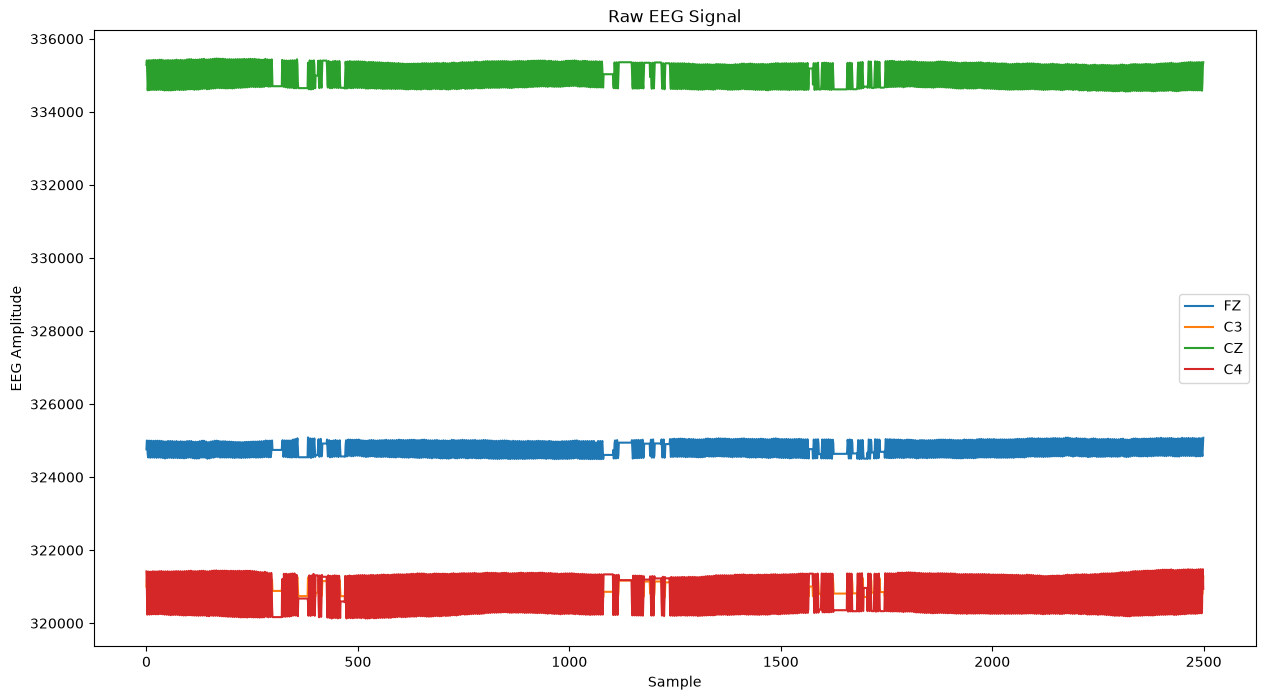

In [15]:
channels = ["FZ", "C3", "CZ", "C4"]

plt.figure(figsize=(15, 8))

for channel in channels:
    plt.plot(sample_df[channel], label=channel)

plt.xlabel("Sample")
plt.ylabel("EEG Amplitude")
plt.title("Raw EEG Signal")
plt.legend()
plt.show()

In [16]:
print("Label dataframe shape:", labels_df.shape)
print("Columns:", labels_df.columns.tolist())
print(labels_df.head(10))

Label dataframe shape: (2400, 1)
Columns: ['label']
   label
0   Left
1  Right
2   Left
3   Left
4   Left
5  Right
6  Right
7   Left
8   Left
9  Right


In [17]:
print("Label distribution:")
print(labels_df["label"].value_counts())

Label distribution:
label
Right    1213
Left     1187
Name: count, dtype: int64


In [19]:
import re
import os

file_numbers = []

for f in eeg_files:
    name = os.path.basename(f)
    match = re.search(r"cellula_MI_data_(\d+)\.csv", name)

    if match:
        file_numbers.append(int(match.group(1)))

print("Number of parsed files:", len(file_numbers))
print("Minimum file number:", min(file_numbers))
print("Maximum file number:", max(file_numbers))

missing = sorted(set(range(min(file_numbers),
                           max(file_numbers) + 1))
                 - set(file_numbers))

print("Number of missing file numbers:", len(missing))
print("First 20 missing:", missing[:20])

Number of parsed files: 2160
Minimum file number: 1
Maximum file number: 2160
Number of missing file numbers: 0
First 20 missing: []


In [20]:
print(sorted(file_numbers)[:20])
print(sorted(file_numbers)[-20:])

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
[2141, 2142, 2143, 2144, 2145, 2146, 2147, 2148, 2149, 2150, 2151, 2152, 2153, 2154, 2155, 2156, 2157, 2158, 2159, 2160]


In [21]:
import pandas as pd
import os

# Sort files numerically
eeg_files_sorted = sorted(
    eeg_files,
    key=lambda x: int(
        os.path.basename(x)
        .replace("cellula_MI_data_", "")
        .replace(".csv", "")
    )
)

# Use only the first 2160 labels
labels_used = labels_df.iloc[:len(eeg_files_sorted)].copy()

matched_df = pd.DataFrame({
    "file_path": eeg_files_sorted,
    "label": labels_used["label"].values
})

print("Matched samples:", len(matched_df))
print(matched_df.head())
print(matched_df.tail())

Matched samples: 2160
                      file_path  label
0  MI CSV\cellula_MI_data_1.csv   Left
1  MI CSV\cellula_MI_data_2.csv  Right
2  MI CSV\cellula_MI_data_3.csv   Left
3  MI CSV\cellula_MI_data_4.csv   Left
4  MI CSV\cellula_MI_data_5.csv   Left
                            file_path  label
2155  MI CSV\cellula_MI_data_2156.csv   Left
2156  MI CSV\cellula_MI_data_2157.csv   Left
2157  MI CSV\cellula_MI_data_2158.csv  Right
2158  MI CSV\cellula_MI_data_2159.csv  Right
2159  MI CSV\cellula_MI_data_2160.csv  Right


In [22]:
print(matched_df["label"].value_counts())


label
Left     1082
Right    1078
Name: count, dtype: int64


In [23]:
sample_file = matched_df.iloc[0]["file_path"]

sample_df = pd.read_csv(sample_file)

print("Shape:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

print("\nFirst 5 rows:")
print(sample_df.head())

print("\nData types:")
print(sample_df.dtypes)

Shape: (2500, 5)

Columns:
['Time', 'FZ', 'C3', 'CZ', 'C4']

First 5 rows:
           Time            FZ            C3            CZ            C4
0  88451.201876  324761.37500  321002.62500  335287.28125  321417.90625
1  88451.221777  325001.18750  321223.09375  335409.56250  320937.09375
2  88451.221788  324896.75000  321045.53125  334954.40625  320233.56250
3  88451.229576  324627.28125  320756.12500  334589.43750  320262.25000
4  88451.229588  324538.31250  320729.21875  334804.56250  321010.50000

Data types:
Time    float64
FZ      float64
C3      float64
CZ      float64
C4      float64
dtype: object


In [24]:
print("Total missing values:")
print(sample_df.isnull().sum())

Total missing values:
Time    0
FZ      0
C3      0
CZ      0
C4      0
dtype: int64


In [25]:
sample_df.describe()

,Time,FZ,C3,CZ,C4
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,88456.329137,324770.376525,320966.199350,334986.259500,320801.713538
std,2.855393,182.365338,181.396794,281.435985,428.541342
min,88451.201876,324489.781250,320697.843750,334553.156250,320128.687500
25%,88453.738725,324593.289062,320796.953125,334707.195312,320362.085938
50%,88456.342866,324757.046875,320947.906250,334967.062500,320798.906250
75%,88458.687961,324942.390625,321146.265625,335273.015625,321228.125000
max,88461.196922,325086.750000,321280.687500,335460.718750,321480.062500


In [26]:
print("Number of trials:", len(matched_df))

# Check duplicate files
print("Duplicate file paths:",
      matched_df["file_path"].duplicated().sum())

# Check duplicate labels rows
print("Missing labels:",
      matched_df["label"].isnull().sum())

Number of trials: 2160
Duplicate file paths: 0
Missing labels: 0


In [27]:
channel_cols = ["FZ", "C3", "CZ", "C4"]

print("Channels:", channel_cols)
print("Number of channels:", len(channel_cols))
print("Samples per trial:", len(sample_df))

Channels: ['FZ', 'C3', 'CZ', 'C4']
Number of channels: 4
Samples per trial: 2500


In [28]:
time_diff = sample_df["Time"].diff().dropna()

print("Average time step:", time_diff.mean())

fs = 1 / time_diff.mean()

print("Estimated Sampling Frequency:", fs)

Average time step: 0.003999618287319599
Estimated Sampling Frequency: 250.02385931937627
